<a href="https://colab.research.google.com/github/vansikavimal/Explainable-MCF7-Cell-Segmentation-unet/blob/main/final_cell_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tensorflow with GPU

This notebook provides an introduction to computing on a [GPU](https://cloud.google.com/gpu) in Colab. In this notebook you will connect to a GPU, and then run some basic TensorFlow operations on both the CPU and a GPU, observing the speedup provided by using the GPU.


## Enabling and testing the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

Next, we'll confirm that we can connect to the GPU with tensorflow:

## Observe TensorFlow speedup on GPU relative to CPU

This example constructs a typical convolutional neural network layer over a
random image and manually places the resulting ops on either the CPU or the GPU
to compare execution speed.

In [ ]:
import tensorflow as tf
import timeit

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print(
      '\n\nThis error most likely means that this notebook is not '
      'configured to use a GPU.  Change this in Notebook Settings via the '
      'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
  raise SystemError('GPU device not found')

def cpu():
  with tf.device('/cpu:0'):
    random_image_cpu = tf.random.normal((100, 100, 100, 3))
    net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)
    return tf.math.reduce_sum(net_cpu)

def gpu():
  with tf.device('/device:GPU:0'):
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)
    return tf.math.reduce_sum(net_gpu)

# We run each op once to warm up; see: https://stackoverflow.com/a/45067900
cpu()
gpu()

# Run the op several times.
print('Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images '
      '(batch x height x width x channel). Sum of ten runs.')
print('CPU (s):')
cpu_time = timeit.timeit('cpu()', number=10, setup="from __main__ import cpu")
print(cpu_time)
print('GPU (s):')
gpu_time = timeit.timeit('gpu()', number=10, setup="from __main__ import gpu")
print(gpu_time)
print('GPU speedup over CPU: {}x'.format(int(cpu_time/gpu_time)))

Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images (batch x height x width x channel). Sum of ten runs.
CPU (s):
6.827886350000028
GPU (s):
0.2187247250000155
GPU speedup over CPU: 31x


In [ ]:
# Clone LIVECell GitHub repo (contains code + annotation JSON)
!git clone https://github.com/sartorius-research/LIVECell.git


Cloning into 'LIVECell'...
remote: Enumerating objects: 202, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 202 (delta 0), reused 0 (delta 0), pack-reused 201 (from 1)
Receiving objects: 100% (202/202), 62.22 KiB | 10.37 MiB/s, done.
Resolving deltas: 100% (94/94), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/ColabData/MCF7.zip -d /content/MCF7

Archive:  /content/drive/MyDrive/ColabData/MCF7.zip
   creating: /content/MCF7/MCF7/test/
   creating: /content/MCF7/MCF7/test/input/
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d00h00m_1.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d00h00m_2.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d00h00m_3.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d00h00m_4.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d04h00m_1.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d04h00m_2.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d04h00m_3.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d04h00m_4.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d08h00m_1.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d08h00m_2.tif  
  inflating: /content/MCF7/MCF7/test/input/MCF7_Phase_H4_1_00d08h00m_3.tif  
  inflating: /conte

In [ ]:
import os

# List first 10 files
data_path = "/content/MCF7/MCF7/train/output"
files = os.listdir(data_path)
print("Number of files:", len(files))
print("First 10 files:", files[:10])


Number of files: 551
First 10 files: ['MCF7_Phase_F4_2_01d12h00m_2.tif', 'MCF7_Phase_G4_2_00d16h00m_4.tif', 'MCF7_Phase_F4_2_02d20h00m_2.tif', 'MCF7_Phase_G4_1_00d08h00m_1.tif', 'MCF7_Phase_G4_2_03d04h00m_2.tif', 'MCF7_Phase_F4_2_02d20h00m_4.tif', 'MCF7_Phase_E4_1_00d04h00m_3.tif', 'MCF7_Phase_F4_1_00d00h00m_2.tif', 'MCF7_Phase_F4_1_01d20h00m_2.tif', 'MCF7_Phase_G4_2_00d20h00m_2.tif']


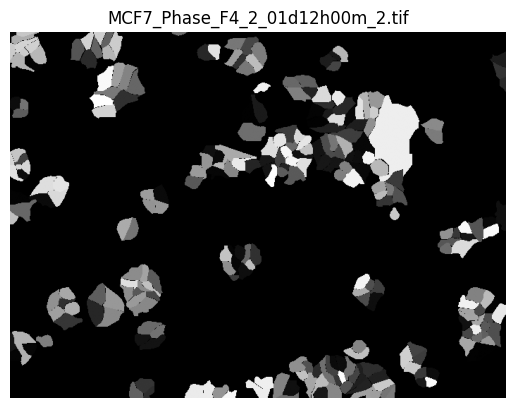

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Load one image
img_path = os.path.join(data_path, files[0])
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title(files[0])
plt.axis('off')
plt.show()


In [ ]:
import os
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class MCF7Dataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, mask_transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.transform = transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = Image.open(img_path).convert("L")  # Grayscale image
        mask = Image.open(mask_path).convert("L")  # Grayscale mask

        if self.transform:
            image = self.transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask

# Usage example:

transform = transforms.ToTensor()
mask_transform = transforms.Compose([
    transforms.ToTensor(),
    lambda x: (x > 0).float()  # binarize the mask
])

dataset = MCF7Dataset(image_dir="/content/MCF7/MCF7/train/input", mask_dir="/content/MCF7/MCF7/train/output",
                      transform=transform, mask_transform=mask_transform)

sample_image, sample_mask = dataset[0]
print("Sample image shape:", sample_image.shape)
print("Sample mask shape:", sample_mask.shape)


Sample image shape: torch.Size([1, 520, 704])
Sample mask shape: torch.Size([1, 520, 704])


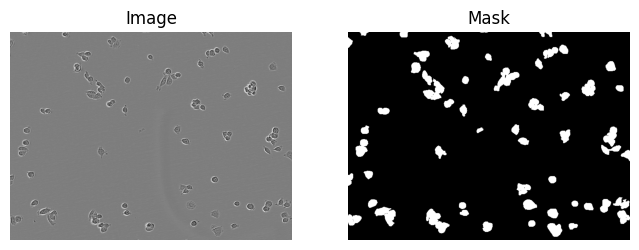

In [ ]:
import matplotlib.pyplot as plt

sample_image, sample_mask = dataset[0]

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(sample_image.squeeze(), cmap="gray")
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(sample_mask.squeeze(), cmap="gray")
ax[1].set_title("Mask")
ax[1].axis("off")

plt.show()


In [ ]:
!pip install segmentation-models-pytorch

import segmentation_models_pytorch as smp
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",        # pretrained encoder
    encoder_weights="imagenet",     # use ImageNet weights
    in_channels=1,                  # grayscale input image
    classes=1,                      # binary mask output
).to(device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import segmentation_models_pytorch as smp

# --- Paths ---
train_image_dir = "/content/MCF7/MCF7/train/input"
train_mask_dir  = "/content/MCF7/MCF7/train/output"

test_image_dir = "/content/MCF7/MCF7/test/input"
test_mask_dir  = "/content/MCF7/MCF7/test/output"

# --- Transforms ---
transform = transforms.ToTensor()
mask_transform = transforms.Compose([
    transforms.ToTensor(),
    lambda x: (x > 0).float()  # binarize mask
])

# --- Dataset ---
train_dataset = MCF7Dataset(train_image_dir, train_mask_dir, transform, mask_transform)
test_dataset  = MCF7Dataset(test_image_dir, test_mask_dir, transform, mask_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(test_dataset, batch_size=8, shuffle=False)

# --- Model, optimizer, loss ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(in_channels=1, classes=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- Metrics ---
def dice_coef(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean().item()

def iou_score(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

# --- Train & Eval ---
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).long()
        correct += (preds == masks.long()).sum().item()
        total   += masks.numel()

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item() * images.size(0)
            # metrics
            total_dice += dice_coef(outputs, masks) * images.size(0)
            total_iou  += iou_score(outputs, masks) * images.size(0)

    n = len(loader.dataset)
    return total_loss / n, total_dice / n, total_iou / n

# --- Training loop with early stopping ---
best_val_loss = float("inf")
patience, counter = 10, 0

num_epochs = 30
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice, val_iou = eval_epoch(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Val Dice: {val_dice:.4f}, "
          f"Val IoU: {val_iou:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_unet.pth")
        print("✅ Model improved, saved to best_unet.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⏹️ Early stopping triggered!")
            break

# Load best model after training
model.load_state_dict(torch.load("best_unet.pth"))
print("✅ Best model loaded for evaluation/testing")

Epoch 1/30, Train Loss: 0.2753, Train Acc: 0.9013, Val Loss: 0.6522, Val Dice: 0.5401, Val IoU: 0.3788
✅ Model improved, saved to best_unet.pth
Epoch 2/30, Train Loss: 0.1829, Train Acc: 0.9255, Val Loss: 0.2019, Val Dice: 0.8976, Val IoU: 0.8177
✅ Model improved, saved to best_unet.pth
Epoch 3/30, Train Loss: 0.1700, Train Acc: 0.9293, Val Loss: 0.1876, Val Dice: 0.8941, Val IoU: 0.8138
✅ Model improved, saved to best_unet.pth
Epoch 4/30, Train Loss: 0.1618, Train Acc: 0.9331, Val Loss: 0.1682, Val Dice: 0.9131, Val IoU: 0.8430
✅ Model improved, saved to best_unet.pth
Epoch 5/30, Train Loss: 0.1593, Train Acc: 0.9336, Val Loss: 0.1639, Val Dice: 0.9184, Val IoU: 0.8517
✅ Model improved, saved to best_unet.pth
Epoch 6/30, Train Loss: 0.1787, Train Acc: 0.9265, Val Loss: 0.4543, Val Dice: 0.7563, Val IoU: 0.6125
Epoch 7/30, Train Loss: 0.1617, Train Acc: 0.9325, Val Loss: 0.2093, Val Dice: 0.8876, Val IoU: 0.8045
Epoch 8/30, Train Loss: 0.1546, Train Acc: 0.9355, Val Loss: 0.1614, Val D

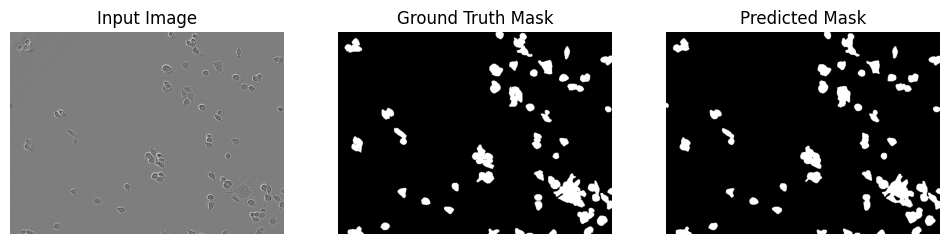

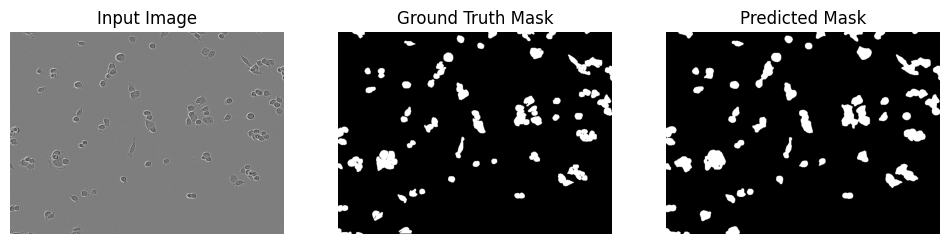

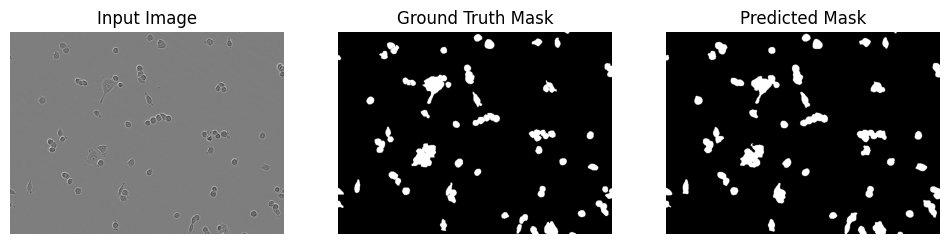

In [ ]:
import matplotlib.pyplot as plt

# Load best model (12th epoch in your case)
model.load_state_dict(torch.load("best_unet.pth", map_location=device))
model.eval()

# Take a few samples from validation set
n_samples = 3  # number of images to visualize
examples = list(iter(val_loader))

images, masks = examples[0]  # get first batch
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()

# Convert tensors to numpy for plotting
images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.cpu().numpy()

# Plot
for i in range(min(n_samples, len(images))):
    plt.figure(figsize=(12,4))

    # Input
    plt.subplot(1,3,1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title("Input Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(1,3,2)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(preds[i][0], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_metrics(model, loader, device):
    model.eval()
    dices, ious, accs, precisions, recalls = [], [], [], [], []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()

            # Flatten
            y_true = masks.view(-1).cpu().numpy()
            y_pred = preds.view(-1).cpu().numpy()

            # Confusion matrix components
            tn, fp, fn, tp = confusion_matrix(
                y_true, y_pred, labels=[0,1]
            ).ravel()

            # Metrics
            acc = (tp + tn) / (tp + tn + fp + fn + 1e-7)
            precision = tp / (tp + fp + 1e-7)
            recall = tp / (tp + fn + 1e-7)
            dice = (2*tp) / (2*tp + fp + fn + 1e-7)
            iou = tp / (tp + fp + fn + 1e-7)

            accs.append(acc)
            precisions.append(precision)
            recalls.append(recall)
            dices.append(dice)
            ious.append(iou)

    return {
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "Dice": np.mean(dices),
        "IoU": np.mean(ious)
    }

# Example usage
metrics = evaluate_metrics(model, val_loader, device)
for k, v in metrics.items():
    print(f"{k}: {float(v)*100:.2f}%")



Accuracy: 93.61%
Precision: 88.70%
Recall: 95.48%
Dice: 91.92%
IoU: 85.12%


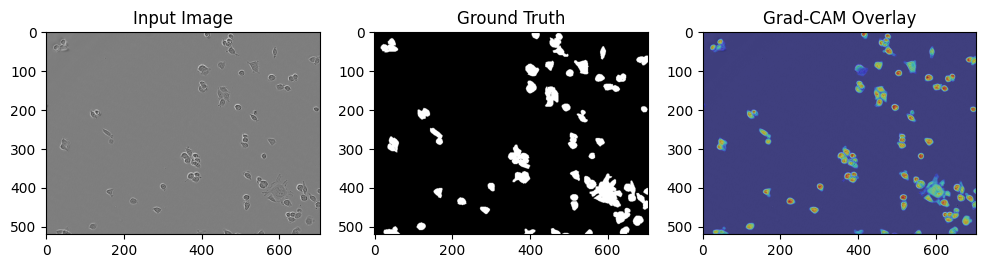

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# --- Grad-CAM helper ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # register hooks
        self.fwd_hook = target_layer.register_forward_hook(self.save_activation)
        self.bwd_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image):
        self.model.zero_grad()
        output = self.model(input_image)

        # Take the max logit for backward
        loss = output.mean()
        loss.backward()

        # Grad-CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        # Normalize to [0,1]
        cam = F.interpolate(cam, size=input_image.shape[2:], mode='bilinear', align_corners=False)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

# --- Load best model ---
model.load_state_dict(torch.load("best_unet.pth", map_location=device))
model.eval()

# Pick last decoder conv layer as target
target_layer = model.decoder.blocks[-1].conv2

# Initialize Grad-CAM
gradcam = GradCAM(model, target_layer)

# --- Get one validation image ---
images, masks = next(iter(val_loader))
image, mask = images[0:1].to(device), masks[0:1].to(device)

# Generate CAM
cam = gradcam.generate(image)

# Convert to numpy for visualization
image_np = image[0,0].cpu().numpy()
mask_np = mask[0,0].cpu().numpy()
cam_np = cam[0,0].cpu().numpy()

# --- Plot ---
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_np, cmap='gray')
plt.title("Input Image")

plt.subplot(1,3,2)
plt.imshow(mask_np, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(image_np, cmap='gray')
plt.imshow(cam_np, cmap='jet', alpha=0.5)
plt.title("Grad-CAM Overlay")

plt.show()

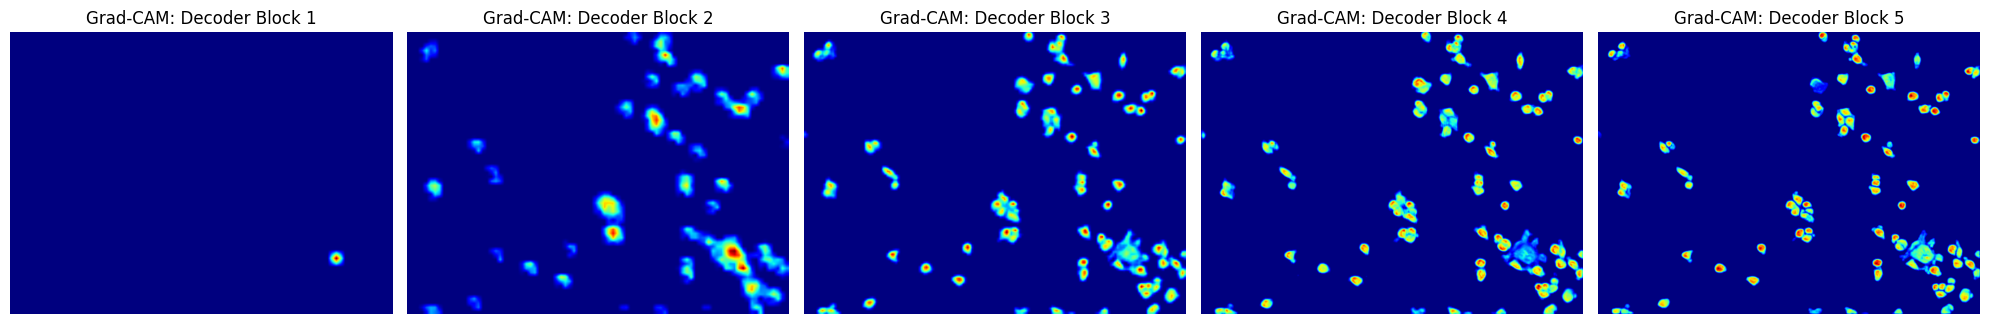

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Select different decoder layers
target_layers = [
    model.decoder.blocks[0].conv1,
    model.decoder.blocks[1].conv2,
    model.decoder.blocks[2].conv2,
    model.decoder.blocks[3].conv2,
    model.decoder.blocks[4].conv2
]

# Get one test image
test_img, test_mask = test_dataset[0]
input_tensor = test_img.unsqueeze(0).to(device)

# Convert to numpy for overlay
rgb_img = test_img.permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

plt.figure(figsize=(20, 4))

for i, layer in enumerate(target_layers):
    cam = GradCAM(model=model, target_layer=layer)
    grayscale_cam = cam.generate(input_image=input_tensor)[0, :]

    plt.subplot(1, len(target_layers), i+1)
    plt.imshow(grayscale_cam.squeeze().cpu().numpy(), cmap='jet')
    plt.title(f"Grad-CAM: Decoder Block {i+1}")
plt.tight_layout()
plt.show()